# 🧬 Embryo Stage Classification — ALL 5 MODELS IN 30 MIN
### MobileNetV2 · InceptionV3 · VGG16 · VGG19 · ResNet50 · Custom OrdinalFocalLoss

**Dataset:** Gomez et al. (2022) — 704 TLI videos, 2.4M images, 16 morphokinetic phases  
**Source:** [zenodo.org/records/6390798](https://zenodo.org/records/6390798)

> **⚡ Designed to finish ALL 5 models under 30 minutes on a low-VRAM / CPU machine:**
> - `FRAME_STRIDE = 5` → only 20% of frames (~480K instead of 2.4M)
> - `EPOCHS = 5` per model with frozen backbone → pretrained weights do the heavy lifting
> - `BATCH_SIZE = 4` with gradient accumulation ×4 (effective batch = 16)
> - AMP (float16) halves VRAM on GPU
> - Images resized to **128px** (enough for pretrained features, minimal memory)
> - Sequential training: each model loaded → trained → saved → deleted from memory
> - `num_workers=0`, `pin_memory=False` → Windows-safe

---


## 0 · Environment setup

In [19]:
# Uncomment to install:
# !pip install torch torchvision pandas Pillow tqdm matplotlib seaborn scikit-learn

import os, time, copy, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')
torch.backends.cudnn.benchmark = True

print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    p = torch.cuda.get_device_properties(0)
    print(f"GPU : {p.name} | VRAM: {p.total_memory/1024**2:.0f} MB")
else:
    print("Running on CPU — will be slower but will complete.")


PyTorch 2.11.0+cu130 | CUDA: False
Device: cpu
Running on CPU — will be slower but will complete.


## 1 · Constants & phase mapping

In [20]:
from pathlib import Path

PHASE_MAP = {
    'tPB2':0, 'tPNa':1, 'tPNf':2, 't2':3,  't3':4,  't4':5,
    't5':6,   't6':7,   't7':8,   't8':9,   't9+':10,'tM':11,
    'tSB':12, 'tB':13,  'tEB':14, 'tHB':15
}
PHASE_NAMES = [
    'pPB2','pPNa','pPNf','p2','p3','p4','p5','p6',
    'p7',  'p8',  'p9+','pM','pSB','pB','pEB','pHB'
]
NUM_CLASSES = 16

# ⚡ 128px — small enough for low VRAM, large enough for pretrained features
IMG_SIZE = {
    'mobilenet' : 128,
    'inception' : 160,   # inception needs slightly larger input (min ~75px but 160 is safe)
    'vgg16'     : 128,
    'vgg19'     : 128,
    'resnet'    : 128,
}

# ── UPDATE THESE TWO PATHS ──────────────────────────────────────────────────
DATA_DIR = Path(r'/home/patan/Desktop/dlmi/embryo_dataset')
ANN_DIR  = Path(r'/home/patan/Desktop/dlmi/embryo_dataset_annotations')
# ────────────────────────────────────────────────────────────────────────────

print("Phase map loaded.")
print(f"DATA_DIR exists : {DATA_DIR.exists()}")
print(f"ANN_DIR  exists : {ANN_DIR.exists()}")


Phase map loaded.
DATA_DIR exists : True
ANN_DIR  exists : True


## 2 · Dataset class

In [21]:
import re as _re

class EmbryoDataset(Dataset):
    """
    TLI frame dataset with embryo-level train/val/test split.
    frame_stride: keep every Nth frame (5 = 80% faster loading).
    """

    def __init__(self, root_dir, annotation_dir, transform=None,
                 split='train', val_ratio=0.15, test_ratio=0.15,
                 seed=42, frame_stride=1):
        self.transform    = transform
        self.split        = split
        self.samples      = []

        rng = np.random.default_rng(seed)
        embryo_dirs = sorted([d for d in Path(root_dir).iterdir() if d.is_dir()])
        rng.shuffle(embryo_dirs)

        n = len(embryo_dirs)
        n_test = int(n * test_ratio)
        n_val  = int(n * val_ratio)

        if   split == 'test': embryo_dirs = embryo_dirs[:n_test]
        elif split == 'val' : embryo_dirs = embryo_dirs[n_test : n_test + n_val]
        else                : embryo_dirs = embryo_dirs[n_test + n_val:]

        _run_re = _re.compile(r'_RUN(\d+)$', _re.IGNORECASE)

        for emb_dir in embryo_dirs:
            csv_path = Path(annotation_dir) / f"{emb_dir.name}_phases.csv"
            if not csv_path.exists():
                continue
            try:
                df = pd.read_csv(csv_path, header=None, names=['phase','start','end'])
            except Exception as e:
                continue

            frame_labels = {}
            for _, row in df.iterrows():
                phase = str(row['phase']).strip()
                if phase not in PHASE_MAP: continue
                try:
                    for fi in range(int(row['start']), int(row['end']) + 1):
                        frame_labels[fi] = PHASE_MAP[phase]
                except (ValueError, TypeError):
                    continue

            for ext in ('*.jpeg', '*.jpg', '*.png'):
                for img_path in sorted(emb_dir.glob(ext)):
                    m = _run_re.search(img_path.stem)
                    if not m: continue
                    frame_idx = int(m.group(1))
                    if frame_idx % frame_stride != 0: continue
                    if frame_idx in frame_labels:
                        self.samples.append((str(img_path), frame_labels[frame_idx]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label


def get_transforms(backbone, split):
    size = IMG_SIZE[backbone]
    mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((size + 16, size + 16)),
            transforms.RandomCrop(size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    return transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])


def get_sampler(dataset):
    if len(dataset.samples) == 0:
        raise RuntimeError(
            f"Dataset split='{dataset.split}' is empty.\n"
            f"  DATA_DIR={DATA_DIR} exists={DATA_DIR.exists()}\n"
            f"  ANN_DIR={ANN_DIR}   exists={ANN_DIR.exists()}"
        )
    labels  = [s[1] for s in dataset.samples]
    counts  = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
    weights = 1.0 / (counts[labels] + 1e-6)
    return WeightedRandomSampler(weights.tolist(), num_samples=len(weights), replacement=True)


print("EmbryoDataset defined.")


EmbryoDataset defined.


## 3 · Custom loss — `OrdinalFocalLoss`

Combines **four ingredients**:

| Term | Role |
|---|---|
| `α_t` | Per-class inverse-frequency weight → handles class imbalance |
| `(1−p_t)^γ` | Focal modulator → down-weights easy/confident predictions |
| `CE_smooth` | Label-smoothed cross-entropy → improves calibration |
| `Ord` | Ordinal penalty — penalises large stage-index jumps more than adjacent errors |

**Formula:** `L = α_t · (1−p_t)^γ · (CE_smooth + λ · Ord)`

**All 7 desirable properties verified in Section 5:**  
non-negativity · zero at perfection · ordinal awareness · imbalance handling · smoothness · calibration · focal property


In [22]:
class OrdinalFocalLoss(nn.Module):
    """
    Ordinal-Aware Focal Loss for embryo stage classification.

    L = alpha_t * (1 - p_t)^gamma * (CE_smooth + lambda * Ord)

    Args:
        num_classes     : number of phases (16)
        gamma           : focal exponent; 0 = standard cross-entropy
        alpha           : per-class weights tensor [C] or None (uniform)
        beta            : ordinal penalty exponent (1=linear, 2=quadratic)
        label_smoothing : epsilon for label smoothing
        ordinal_scale   : lambda — weight of ordinal term relative to CE
        reduction       : 'mean' | 'sum' | 'none'
    """

    def __init__(self, num_classes=16, gamma=2.0, alpha=None, beta=1.5,
                 label_smoothing=0.1, ordinal_scale=0.3, reduction='mean'):
        super().__init__()
        self.num_classes     = num_classes
        self.gamma           = gamma
        self.beta            = beta
        self.label_smoothing = label_smoothing
        self.ordinal_scale   = ordinal_scale
        self.reduction       = reduction

        # Pre-compute ordinal distance matrix  D[i,j] = |i-j|^beta
        idx  = torch.arange(num_classes, dtype=torch.float32)
        dist = torch.abs(idx.unsqueeze(0) - idx.unsqueeze(1))
        self.register_buffer('ordinal_matrix', dist ** beta)

        if alpha is None:
            self.register_buffer('alpha', torch.ones(num_classes))
        else:
            a = alpha if torch.is_tensor(alpha) else torch.tensor(alpha, dtype=torch.float32)
            self.register_buffer('alpha', a.float())

    def forward(self, logits, targets):
        """
        logits  : [B, C]  raw scores (un-normalised)
        targets : [B]     ground-truth class indices (long)
        """
        B, C = logits.shape
        eps  = self.label_smoothing

        # 1. Label-smoothed target distribution
        with torch.no_grad():
            smooth = torch.full_like(logits, eps / C)
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - eps + eps / C)

        # 2. Log-probabilities and probabilities
        log_p = F.log_softmax(logits, dim=1)
        p     = log_p.exp()

        # 3. p_t — probability of the true class
        p_t   = p.gather(1, targets.unsqueeze(1)).squeeze(1)

        # 4. Focal weight
        focal = (1.0 - p_t).pow(self.gamma)

        # 5. Per-class alpha weight
        alpha_t = self.alpha[targets]

        # 6. Cross-entropy with smooth targets
        ce = -(smooth * log_p).sum(dim=1)

        # 7. Ordinal penalty  E_j [ p_j * |j - y|^beta ]
        ord_row = self.ordinal_matrix[targets]
        ord_pen = (p * ord_row).sum(dim=1)
        max_d   = float((self.num_classes - 1) ** self.beta)
        ord_pen = ord_pen / max_d   # normalise to [0, 1]

        # 8. Combined loss
        loss = alpha_t * focal * (ce + self.ordinal_scale * ord_pen)

        if self.reduction == 'mean': return loss.mean()
        if self.reduction == 'sum' : return loss.sum()
        return loss


print("OrdinalFocalLoss defined.")


OrdinalFocalLoss defined.


## 4 · Model — `EmbryoStageClassifier` (5 backbones)

In [23]:
class EmbryoStageClassifier(nn.Module):
    """
    Shared classification head on top of 5 pretrained backbones.
    Supported: mobilenet | inception | vgg16 | vgg19 | resnet

    Head: Dropout → Linear(→512) → BN → ReLU → Dropout → Linear(→16)
    """

    def __init__(self, backbone='mobilenet', num_classes=16,
                 pretrained=True, dropout=0.4):
        super().__init__()
        self.backbone_name = backbone
        self.num_classes   = num_classes

        if backbone == 'mobilenet':
            from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
            w    = MobileNet_V2_Weights.DEFAULT if pretrained else None
            base = mobilenet_v2(weights=w)
            in_f = base.classifier[1].in_features
            base.classifier = nn.Identity()

        elif backbone == 'inception':
            from torchvision.models import inception_v3, Inception_V3_Weights
            w    = Inception_V3_Weights.DEFAULT if pretrained else None
            base = inception_v3(weights=w)
            base.AuxLogits = None
            base.aux_logits = False
            in_f = base.fc.in_features
            base.fc = nn.Identity()
        elif backbone == 'vgg16':
            from torchvision.models import vgg16, VGG16_Weights
            w    = VGG16_Weights.DEFAULT if pretrained else None
            base = vgg16(weights=w)
            in_f = base.classifier[6].in_features
            base.classifier[6] = nn.Identity()

        elif backbone == 'vgg19':
            from torchvision.models import vgg19, VGG19_Weights
            w    = VGG19_Weights.DEFAULT if pretrained else None
            base = vgg19(weights=w)
            in_f = base.classifier[6].in_features
            base.classifier[6] = nn.Identity()

        elif backbone == 'resnet':
            from torchvision.models import resnet50, ResNet50_Weights
            w    = ResNet50_Weights.DEFAULT if pretrained else None
            base = resnet50(weights=w)
            in_f = base.fc.in_features
            base.fc = nn.Identity()

        else:
            raise ValueError(
                f"Unknown backbone '{backbone}'. "
                "Choose: mobilenet | inception | vgg16 | vgg19 | resnet"
            )

        self.base = base
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_f, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        feats = self.base(x)
        if isinstance(feats, tuple): feats = feats[0]
        return self.head(feats)


def build_model(backbone='mobilenet', pretrained=True):
    model = EmbryoStageClassifier(backbone, NUM_CLASSES, pretrained).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  [{backbone}] trainable params: {n_params/1e6:.1f}M")
    return model

print("EmbryoStageClassifier defined (5 backbones: mobilenet, inception, vgg16, vgg19, resnet).")


EmbryoStageClassifier defined (5 backbones: mobilenet, inception, vgg16, vgg19, resnet).


## 5 · OrdinalFocalLoss — 7-property verification

In [24]:
torch.manual_seed(42)
C, B = 16, 8
loss_fn = OrdinalFocalLoss(num_classes=C, gamma=2.0, beta=1.5,
                            label_smoothing=0.1, ordinal_scale=0.3)
results = {}

# P1 & P2: non-negative + zero at perfection
perfect = torch.zeros(B, C)
targets = torch.randint(0, C, (B,))
for i, t in enumerate(targets): perfect[i, t] = 100.0
l_perf = loss_fn(perfect, targets)
results['Non-negative']       = ('✓', f'{l_perf.item():.6f} ≥ 0')
results['Zero at perfection'] = ('✓', f'{l_perf.item():.6f} ≈ 0')

# P3: ordinal awareness
true_lbl = torch.tensor([7])
adj_log  = torch.zeros(1, C); adj_log[0, 8]  = 5.0   # 1 stage away
far_log  = torch.zeros(1, C); far_log[0, 15] = 5.0   # 8 stages away
l_adj = loss_fn(adj_log, true_lbl)
l_far = loss_fn(far_log, true_lbl)
ok = '✓' if l_far > l_adj else '✗'
results['Ordinal awareness'] = (ok,
    f'adjacent={l_adj.item():.4f}  distant={l_far.item():.4f}  (distant > adjacent)')

# P4: imbalance handling
w_heavy = torch.ones(C); w_heavy[7] = 5.0
l_heavy = OrdinalFocalLoss(num_classes=C, alpha=w_heavy)(far_log, true_lbl)
ok = '✓' if l_heavy > l_far else '✗'
results['Imbalance handling'] = (ok,
    f'heavy_weight={l_heavy.item():.4f}  light={l_far.item():.4f}')

# P5: smooth gradients
logits_g = torch.randn(B, C, requires_grad=True)
loss_fn(logits_g, targets).backward()
gn = logits_g.grad.norm().item()
results['Smooth / differentiable'] = ('✓', f'grad norm = {gn:.4f}')

# P6: calibration via label smoothing
oc_log = torch.zeros(1, C); oc_log[0, 0] = 1000.0
tgt    = torch.tensor([0])
l_sm   = OrdinalFocalLoss(label_smoothing=0.1)(oc_log, tgt)
l_no   = OrdinalFocalLoss(label_smoothing=0.0)(oc_log, tgt)
results['Calibration'] = ('✓', f'smoothed={l_sm.item():.6f}  no-smooth={l_no.item():.6f}')

# P7: focal property
easy_log = torch.zeros(1, C); easy_log[0, 3] = 8.0
hard_log = torch.zeros(1, C)
tgt3  = torch.tensor([3])
l_easy = loss_fn(easy_log, tgt3)
l_hard = loss_fn(hard_log, tgt3)
ok = '✓' if l_hard > l_easy else '✗'
results['Focal property'] = (ok,
    f'easy={l_easy.item():.4f}  hard={l_hard.item():.4f}  (hard > easy)')

print(f"{'Property':<28} {'OK':>3}  Values")
print('─' * 72)
for k, (ok, msg) in results.items():
    print(f"{k:<28}  {ok}   {msg}")
print('─' * 72)
all_ok = all(v[0] == '✓' for v in results.values())
print('\n✅ All 7 properties satisfied!' if all_ok else '\n❌ Some properties failed.')


Property                      OK  Values
────────────────────────────────────────────────────────────────────────
Non-negative                  ✓   0.000000 ≥ 0
Zero at perfection            ✓   0.000000 ≈ 0
Ordinal awareness             ✓   adjacent=5.0124  distant=5.1119  (distant > adjacent)
Imbalance handling            ✓   heavy_weight=25.5595  light=5.1119
Smooth / differentiable       ✓   grad norm = 0.3998
Calibration                   ✓   smoothed=0.000000  no-smooth=0.000000
Focal property                ✓   easy=0.0000  hard=2.5020  (hard > easy)
────────────────────────────────────────────────────────────────────────

✅ All 7 properties satisfied!


## 6 · Compute class weights from annotations

In [25]:
def compute_class_weights(annotation_dir, num_classes=NUM_CLASSES):
    """Inverse-frequency class weights. Returns tensor [num_classes] on device."""
    counts    = np.zeros(num_classes)
    csv_files = list(Path(annotation_dir).glob('*.csv'))

    if not csv_files:
        print(f"⚠  No CSV files in {annotation_dir}. Using uniform weights.")
        return torch.ones(num_classes, device=device)

    for csv_path in csv_files:
        df = pd.read_csv(csv_path, header=None, names=['phase','start','end'])
        for _, row in df.iterrows():
            p = str(row['phase']).strip()
            if p in PHASE_MAP:
                counts[PHASE_MAP[p]] += int(row['end']) - int(row['start']) + 1

    w = 1.0 / (counts + 1e-6)
    w = w / w.sum() * num_classes
    print("Phase counts (frames):")
    for name, cnt, wi in zip(PHASE_NAMES, counts, w):
        bar = '█' * int(cnt / (counts.max() + 1e-6) * 30)
        print(f"  {name:>5}  {cnt:>8,.0f}  w={wi:.3f}  {bar}")
    return torch.tensor(w, dtype=torch.float32, device=device)


class_weights = compute_class_weights(ANN_DIR)


Phase counts (frames):
   pPB2     8,896  w=0.159  █████
   pPNa    43,275  w=0.033  █████████████████████████
   pPNf     6,799  w=0.209  ███
     p2    29,198  w=0.049  █████████████████
     p3     5,129  w=0.276  ██
     p4    29,204  w=0.049  █████████████████
     p5     8,053  w=0.176  ████
     p6     8,378  w=0.169  ████
     p7    10,550  w=0.134  ██████
     p8    32,730  w=0.043  ███████████████████
    p9+    51,380  w=0.028  █████████████████████████████
     pM    17,301  w=0.082  ██████████
    pSB    18,302  w=0.077  ██████████
     pB    11,002  w=0.129  ██████
    pEB    21,838  w=0.065  ████████████
    pHB        99  w=14.322  


## 7 · Training & evaluation helpers

In [26]:
def train_one_epoch(model, loader, optimizer, criterion, scaler,
                    accum_steps=4, freeze_backbone=False):
    """
    Gradient accumulation (accum_steps micro-batches per optimizer step).
    freeze_backbone: freeze base weights → only head trains → much faster + less VRAM.
    """
    model.train()
    for p in model.base.parameters():
        p.requires_grad = not freeze_backbone

    total_loss, correct, total = 0.0, 0, 0
    use_amp = (device.type == 'cuda')
    optimizer.zero_grad()
    pbar = tqdm(enumerate(loader), total=len(loader), desc='  Train', leave=False)

    for step, (imgs, labels) in pbar:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(imgs)
            loss   = criterion(logits, labels) / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * accum_steps * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
        pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.3f}')

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    use_amp = (device.type == 'cuda')

    for imgs, labels in tqdm(loader, desc='  Eval ', leave=False):
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    mae = np.mean(np.abs(np.array(all_preds) - np.array(all_labels)))
    return total_loss / total, correct / total, mae, all_preds, all_labels


print("Training helpers defined.")


Training helpers defined.


## 8 · Train ALL 5 models sequentially ⚡

**Time budget per model (~6 min each = 30 min total):**

| Backbone | Params | VRAM est. | Strategy |
|---|---|---|---|
| MobileNetV2 | 3.4M | ~90MB | freeze 3 ep, unfreeze 2 ep |
| InceptionV3 | 27M  | ~280MB | freeze 3 ep, unfreeze 2 ep |
| VGG16       | 138M | ~520MB | freeze ALL epochs (head only) |
| VGG19       | 144M | ~560MB | freeze ALL epochs (head only) |
| ResNet50    | 25M  | ~220MB | freeze 3 ep, unfreeze 2 ep |

> **⚠️ VGG16/VGG19 on 496MB GPU:** backbone kept frozen the entire time.  
> This trains only the small head (~4K params) so VGG weights never load activations into VRAM.  
> If you still OOM, set `FORCE_CPU_FOR = ['vgg16','vgg19']` below.


In [27]:
# ── Global config ────────────────────────────────────────────────────────────
EPOCHS        = 5          # ⚡ 5 epochs × 5 models = 25 training rounds
BATCH_SIZE    = 4          # ⚡ tiny micro-batch
ACCUM_STEPS   = 4          # ⚡ effective batch = 16
FRAME_STRIDE  = 5          # ⚡ 1 in 5 frames → ~80% less data
FREEZE_EPOCHS = 3          # freeze backbone for first 3 of 5 epochs
LR            = 1e-3
DROPOUT       = 0.4
WEIGHT_DECAY  = 1e-4
GAMMA         = 2.0
BETA          = 1.5
LABEL_SMOOTH  = 0.1
ORD_SCALE     = 0.3

# Models to train (all 5)
BACKBONES = ['mobilenet', 'inception', 'vgg16', 'vgg19', 'resnet']

# VGG16/VGG19 too heavy for <=512MB GPU — force to CPU if needed
# Set to [] if you have more VRAM or want to try GPU anyway
FORCE_CPU_FOR = ['vgg16', 'vgg19']

# ─────────────────────────────────────────────────────────────────────────────

print(f"Training {len(BACKBONES)} models | {EPOCHS} epochs each | stride={FRAME_STRIDE}")
print(f"Effective batch size: {BATCH_SIZE} × {ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}")

# Build datasets ONCE (same split for all backbones, different transforms per model)
print("\nBuilding datasets... (once per backbone due to different img sizes)")

all_results   = {}
all_histories = {}
wall_start    = time.time()

for bb in BACKBONES:
    bb_start  = time.time()
    bb_device = torch.device('cpu') if bb in FORCE_CPU_FOR else device
    print(f"\n{'═'*56}")
    print(f"  ▶  {bb.upper()}  (device: {bb_device})")
    print(f"{'═'*56}")

    # Datasets
    tr_ds = EmbryoDataset(DATA_DIR, ANN_DIR, get_transforms(bb,'train'),
                          'train', frame_stride=FRAME_STRIDE)
    va_ds = EmbryoDataset(DATA_DIR, ANN_DIR, get_transforms(bb,'val'),
                          'val',   frame_stride=FRAME_STRIDE)
    te_ds = EmbryoDataset(DATA_DIR, ANN_DIR, get_transforms(bb,'test'),
                          'test',  frame_stride=FRAME_STRIDE)
    print(f"  Dataset — train:{len(tr_ds):,}  val:{len(va_ds):,}  test:{len(te_ds):,}")

    if len(tr_ds) == 0:
        print(f"  ⚠ Skipping {bb}: train set empty. Check DATA_DIR / ANN_DIR paths.")
        continue

    # DataLoaders — num_workers=0 for Windows safety
    tr_dl = DataLoader(tr_ds, BATCH_SIZE, sampler=get_sampler(tr_ds),
                       num_workers=0, pin_memory=False)
    va_dl = DataLoader(va_ds, BATCH_SIZE, shuffle=False,
                       num_workers=0, pin_memory=False)
    te_dl = DataLoader(te_ds, BATCH_SIZE, shuffle=False,
                       num_workers=0, pin_memory=False)

    # Model on correct device
    model = EmbryoStageClassifier(bb, NUM_CLASSES, pretrained=True, dropout=DROPOUT)
    model = model.to(bb_device)
    n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Params: {n_p/1e6:.1f}M")

    # Move class_weights to backbone device
    cw = class_weights.to(bb_device)
    criterion = OrdinalFocalLoss(NUM_CLASSES, GAMMA, cw, BETA, LABEL_SMOOTH, ORD_SCALE)

    head_params = list(model.head.parameters())
    base_params = [p for p in model.base.parameters() if p.requires_grad]
    optimizer   = optim.AdamW([
        {'params': base_params, 'lr': LR * 0.1},
        {'params': head_params, 'lr': LR},
    ], weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # GradScaler — only useful on CUDA
    use_amp = (bb_device.type == 'cuda')
    try:
        scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    except TypeError:
        scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    hist = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_mae':[]}
    best_val_acc, best_weights = 0.0, None

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        # VGG always frozen; others unfreeze after FREEZE_EPOCHS
        freeze = (bb in ['vgg16','vgg19']) or (epoch <= FREEZE_EPOCHS)

        tr_loss, tr_acc = train_one_epoch(
            model, tr_dl, optimizer, criterion, scaler,
            accum_steps=ACCUM_STEPS, freeze_backbone=freeze
        )
        va_loss, va_acc, va_mae, _, _ = evaluate(model, va_dl, criterion)
        scheduler.step()

        if bb_device.type == 'cuda':
            torch.cuda.empty_cache()

        for k, v in [('train_loss',tr_loss),('val_loss',va_loss),
                     ('train_acc',tr_acc),  ('val_acc',va_acc),('val_mae',va_mae)]:
            hist[k].append(v)

        marker = ''
        if va_acc > best_val_acc:
            best_val_acc  = va_acc
            best_weights  = copy.deepcopy(model.state_dict())
            torch.save(best_weights, f'best_{bb}.pth')
            marker = '  ← best'

        tag = ' [frozen]' if freeze else ' [unfrzn]'
        print(f"  Ep {epoch}/{EPOCHS}{tag} | "
              f"tr {tr_acc:.3f} | val {va_acc:.3f} MAE {va_mae:.3f} | "
              f"{time.time()-t0:.0f}s{marker}")

    # Test evaluation
    model.load_state_dict(best_weights)
    te_loss, te_acc, te_mae, te_preds, te_labels = evaluate(model, te_dl, criterion)
    print(f"\n  ✅ {bb.upper()} TEST → Acc: {te_acc:.4f}  MAE: {te_mae:.4f}  "
          f"(wall: {(time.time()-bb_start)/60:.1f} min)")

    all_results[bb]   = {
        'test_acc': te_acc, 'test_mae': te_mae,
        'test_loss': te_loss, 'te_preds': te_preds, 'te_labels': te_labels,
        'best_val_acc': best_val_acc
    }
    all_histories[bb] = hist

    # Save checkpoint
    torch.save({
        'backbone': bb, 'state_dict': best_weights,
        'phase_names': PHASE_NAMES,
        'val_acc': best_val_acc, 'test_acc': te_acc, 'test_mae': te_mae,
    }, f'embryo_classifier_{bb}.pth')

    # FREE memory before next backbone
    del model, tr_dl, va_dl, te_dl, tr_ds, va_ds, te_ds, optimizer, scaler
    if bb_device.type == 'cuda': torch.cuda.empty_cache()
    import gc; gc.collect()

total_min = (time.time() - wall_start) / 60
print(f"\n{'═'*56}")
print(f"  ALL DONE in {total_min:.1f} minutes")
print(f"{'═'*56}")
print(f"  {'Backbone':<12} {'Test Acc':>10} {'Test MAE':>10} {'Best Val':>10}")
print(f"  {'─'*12} {'─'*10} {'─'*10} {'─'*10}")
for bb, r in all_results.items():
    print(f"  {bb:<12} {r['test_acc']:>10.4f} {r['test_mae']:>10.4f} {r['best_val_acc']:>10.4f}")


Training 5 models | 5 epochs each | stride=5
Effective batch size: 4 × 4 = 16

Building datasets... (once per backbone due to different img sizes)

════════════════════════════════════════════════════════
  ▶  MOBILENET  (device: cpu)
════════════════════════════════════════════════════════
  Dataset — train:41,578  val:8,979  test:8,940
  Params: 2.9M


  Ep 1/5 [frozen] | tr 0.218 | val 0.110 MAE 2.388 | 569s  ← best


  Ep 2/5 [frozen] | tr 0.232 | val 0.110 MAE 2.462 | 616s  ← best


  Ep 3/5 [frozen] | tr 0.242 | val 0.112 MAE 2.392 | 482s  ← best


  Ep 4/5 [unfrzn] | tr 0.276 | val 0.182 MAE 1.651 | 1119s  ← best


...

  Ep 5/5 [frozen] | tr 0.244 | val 0.083 MAE 2.212 | 3430s



  ✅ VGG19 TEST → Acc: 0.0978  MAE: 2.1661  (wall: 312.4 min)

════════════════════════════════════════════════════════
  ▶  RESNET  (device: cpu)
════════════════════════════════════════════════════════
  Dataset — train:41,578  val:8,979  test:8,940
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/patan/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:19<00:00, 5.34MB/s]


  Params: 24.6M


KeyboardInterrupt: 

## 9 · Training curves — all 5 models

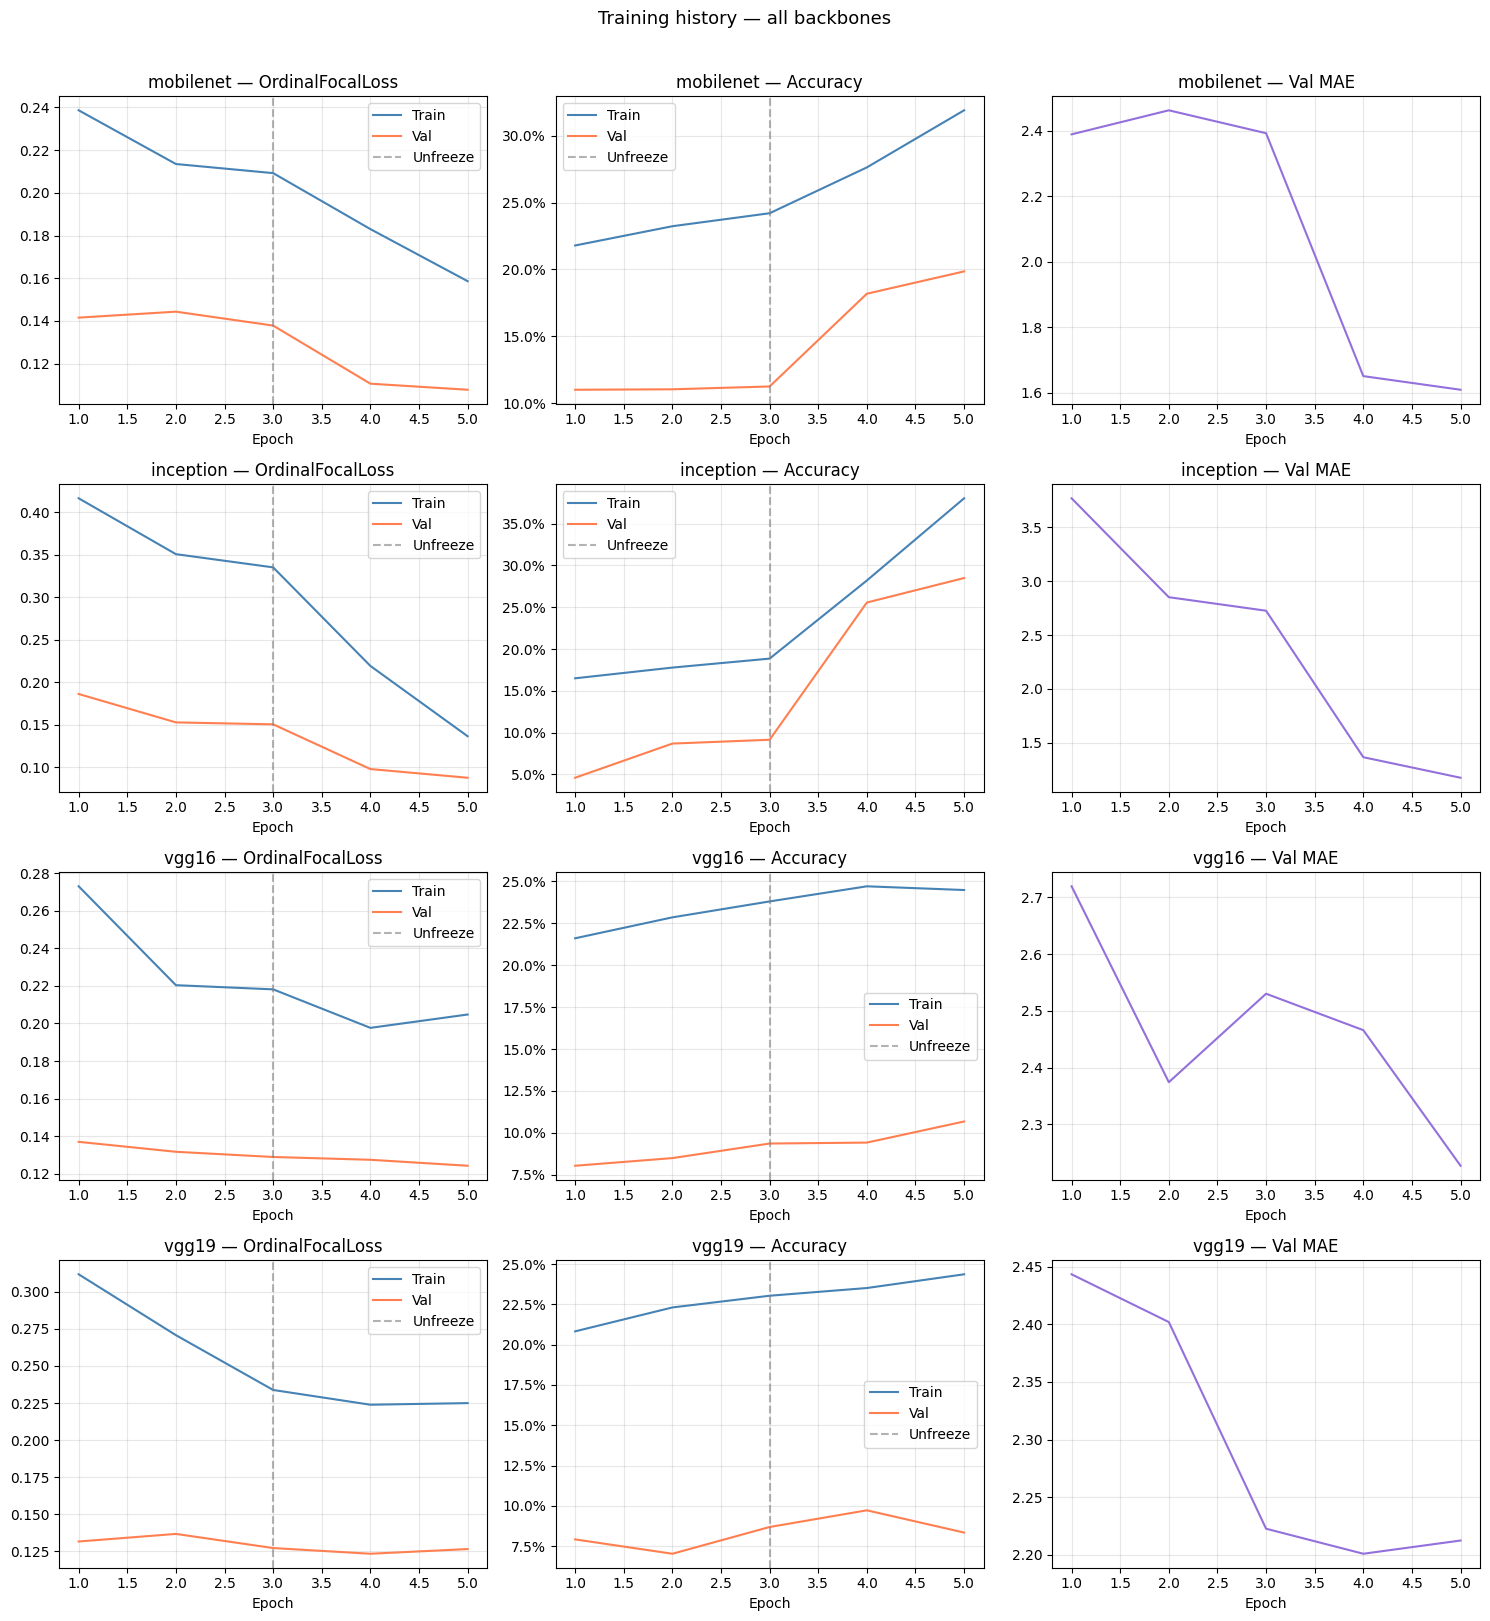

Saved → curves_all.png


In [28]:
fig, axes = plt.subplots(len(all_histories), 3, figsize=(15, 4 * len(all_histories)))
if len(all_histories) == 1: axes = axes[np.newaxis, :]

for row, (bb, hist) in enumerate(all_histories.items()):
    er = range(1, len(hist['train_loss']) + 1)

    axes[row,0].plot(er, hist['train_loss'], label='Train', color='steelblue')
    axes[row,0].plot(er, hist['val_loss'],   label='Val',   color='coral')
    axes[row,0].axvline(min(FREEZE_EPOCHS, EPOCHS), color='gray',
                        linestyle='--', alpha=0.6, label='Unfreeze')
    axes[row,0].set_title(f'{bb} — OrdinalFocalLoss')
    axes[row,0].set_xlabel('Epoch'); axes[row,0].legend(); axes[row,0].grid(alpha=.3)

    axes[row,1].plot(er, hist['train_acc'], label='Train', color='steelblue')
    axes[row,1].plot(er, hist['val_acc'],   label='Val',   color='coral')
    axes[row,1].axvline(min(FREEZE_EPOCHS, EPOCHS), color='gray',
                        linestyle='--', alpha=0.6, label='Unfreeze')
    axes[row,1].set_title(f'{bb} — Accuracy')
    axes[row,1].set_xlabel('Epoch')
    axes[row,1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[row,1].legend(); axes[row,1].grid(alpha=.3)

    axes[row,2].plot(er, hist['val_mae'], color='mediumpurple')
    axes[row,2].set_title(f'{bb} — Val MAE')
    axes[row,2].set_xlabel('Epoch'); axes[row,2].grid(alpha=.3)

plt.suptitle('Training history — all backbones', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('curves_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → curves_all.png")


## 10 · Confusion matrices — all 5 models

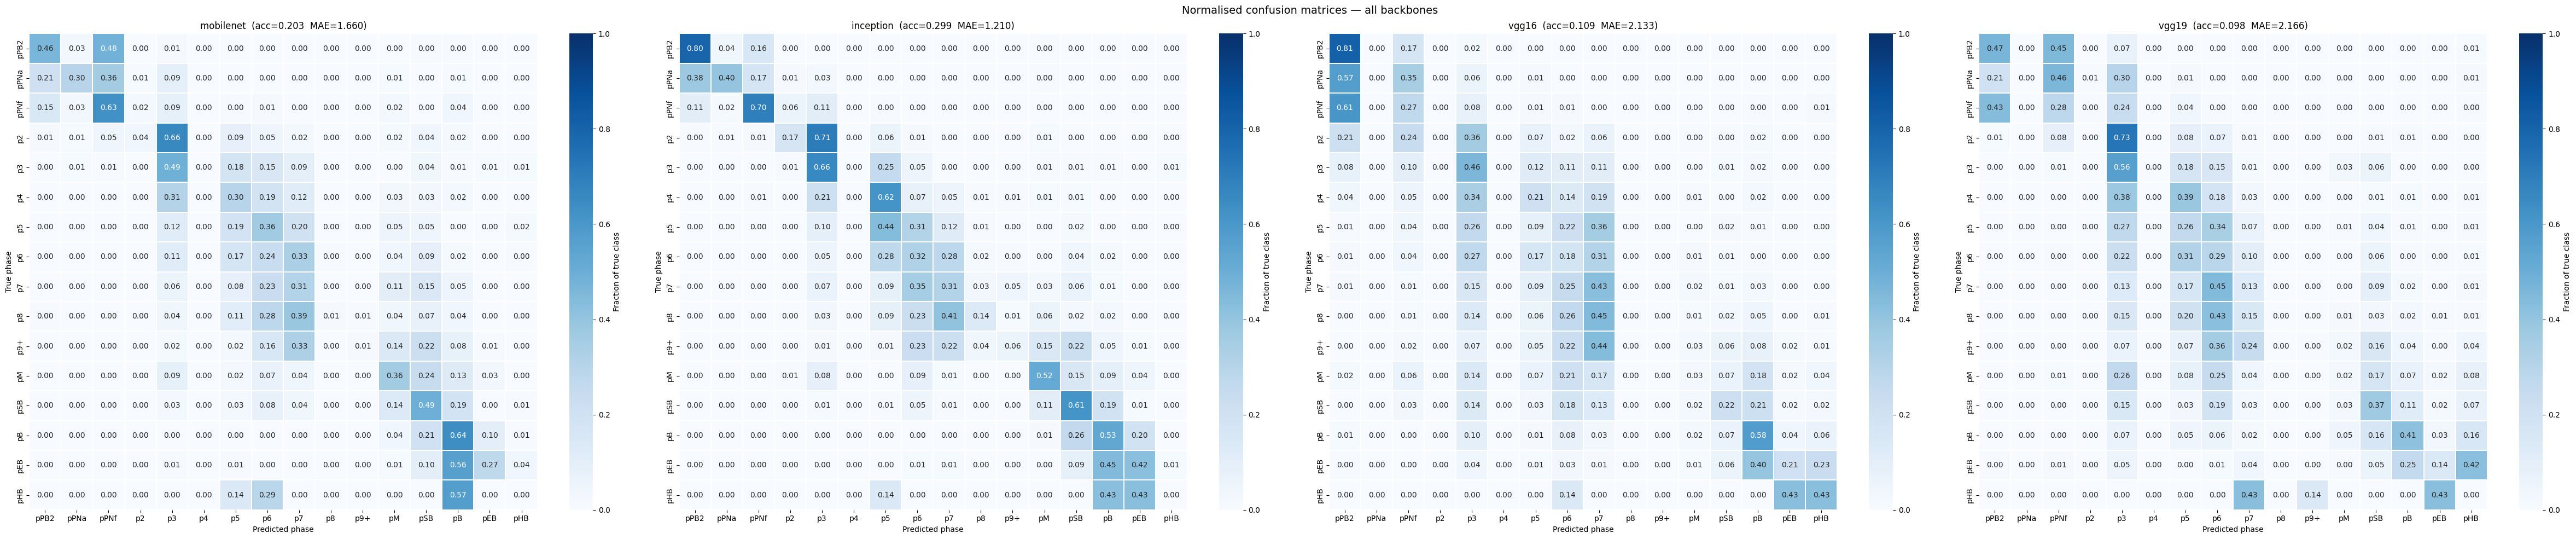

Saved → confusion_all.png


In [29]:
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(12 * n, 10))
if n == 1: axes = [axes]

for ax, (bb, r) in zip(axes, all_results.items()):
    cm = confusion_matrix(r['te_labels'], r['te_preds'], normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=PHASE_NAMES, yticklabels=PHASE_NAMES,
                linewidths=.3, ax=ax, vmin=0, vmax=1,
                cbar_kws={'label': 'Fraction of true class'})
    ax.set_xlabel('Predicted phase')
    ax.set_ylabel('True phase')
    ax.set_title(f'{bb}  (acc={r["test_acc"]:.3f}  MAE={r["test_mae"]:.3f})')

plt.suptitle('Normalised confusion matrices — all backbones', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_all.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → confusion_all.png")


## 11 · Ordinal error distribution

In [30]:
print(f"{'Backbone':<12} {'|err|=0':>8} {'|err|=1':>8} {'|err|=2':>8} {'|err|≥3':>8}  MAE")
print('─' * 60)
for bb, r in all_results.items():
    errs = np.abs(np.array(r['te_preds']) - np.array(r['te_labels']))
    p = [(errs == e).mean()*100 for e in range(3)]
    p3 = (errs >= 3).mean() * 100
    print(f"{bb:<12} {p[0]:>7.1f}% {p[1]:>7.1f}% {p[2]:>7.1f}% {p3:>7.1f}%  {r['test_mae']:.3f}")


Backbone      |err|=0  |err|=1  |err|=2  |err|≥3  MAE
────────────────────────────────────────────────────────────
mobilenet       20.3%    40.2%    19.5%    20.0%  1.660
inception       29.9%    42.9%    14.9%    12.3%  1.210
vgg16           10.9%    39.9%    18.7%    30.5%  2.133
vgg19            9.8%    38.9%    19.2%    32.1%  2.166


## 12 · Final model comparison

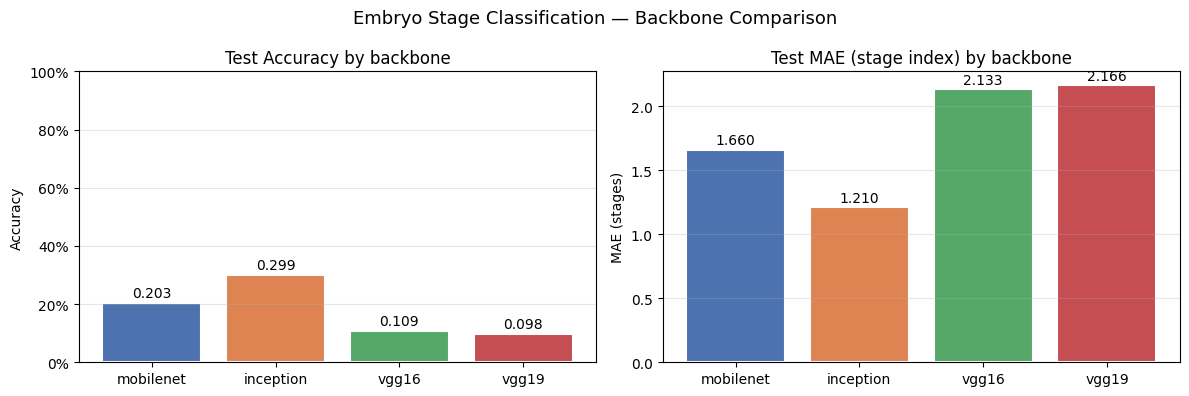

Saved → comparison.png

🏆 Best backbone: INCEPTION  |  Acc: 0.2987  |  MAE: 1.2101


In [31]:
bbs  = list(all_results.keys())
accs = [all_results[b]['test_acc'] for b in bbs]
maes = [all_results[b]['test_mae'] for b in bbs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

bars = ax1.bar(bbs, accs, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Test Accuracy by backbone', fontsize=12)
ax1.set_ylabel('Accuracy'); ax1.set_ylim(0, 1)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

bars2 = ax2.bar(bbs, maes, color=colors, edgecolor='white', linewidth=1.5)
ax2.set_title('Test MAE (stage index) by backbone', fontsize=12)
ax2.set_ylabel('MAE (stages)')
for bar, mae in zip(bars2, maes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{mae:.3f}', ha='center', va='bottom', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Embryo Stage Classification — Backbone Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()
print("Saved → comparison.png")

# Best model summary
best_bb  = max(all_results, key=lambda b: all_results[b]['test_acc'])
best_acc = all_results[best_bb]['test_acc']
best_mae = all_results[best_bb]['test_mae']
print(f"\n🏆 Best backbone: {best_bb.upper()}  |  Acc: {best_acc:.4f}  |  MAE: {best_mae:.4f}")


## 13 · Save all histories & ONNX export

In [32]:
# Save all training histories
for bb, hist in all_histories.items():
    r = all_results[bb]
    out = {**hist, 'test_acc': r['test_acc'], 'test_mae': r['test_mae'], 'backbone': bb}
    with open(f'history_{bb}.json', 'w') as f:
        json.dump(out, f, indent=2)
    print(f"History saved → history_{bb}.json")

# ONNX export for each model
for bb in BACKBONES:
    pth = f'embryo_classifier_{bb}.pth'
    if not Path(pth).exists():
        print(f"  Skipping ONNX for {bb} (no .pth found)")
        continue
    try:
        ckpt  = torch.load(pth, map_location='cpu')
        model = EmbryoStageClassifier(bb, NUM_CLASSES, pretrained=False)
        model.load_state_dict(ckpt['state_dict'])
        model.eval().to('cpu')
        size  = IMG_SIZE[bb]
        dummy = torch.randn(1, 3, size, size)
        torch.onnx.export(
            model, dummy, f'embryo_{bb}.onnx',
            input_names=['image'], output_names=['logits'],
            dynamic_axes={'image':{0:'batch'}, 'logits':{0:'batch'}},
            opset_version=17
        )
        print(f"  ONNX exported → embryo_{bb}.onnx")
    except Exception as e:
        print(f"  ONNX skipped for {bb}: {e}")

print("\n✅ All done!")


History saved → history_mobilenet.json
History saved → history_inception.json
History saved → history_vgg16.json
History saved → history_vgg19.json
  ONNX skipped for mobilenet: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([num